In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm, kurtosis
import scipy.stats as stats

close = pd.read_parquet("close_prices.parquet")
daily_returns = pd.read_parquet("daily_returns.parquet")
annual_summary = pd.read_parquet("annual_summary.parquet")


Kurtosis: 8.44606243018017


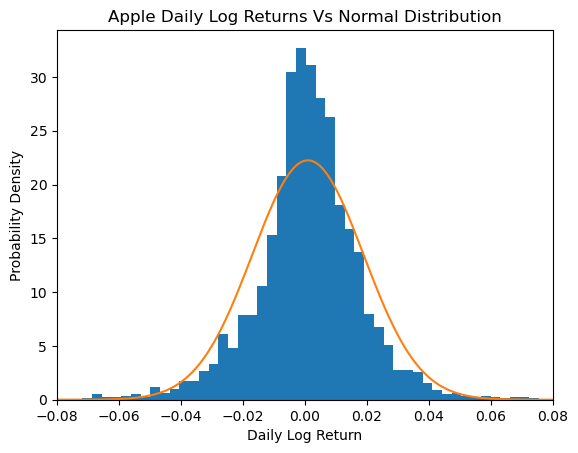

In [2]:
log_returns = np.log(close / close.shift(1))

series = log_returns["AAPL"].dropna()
mu = series.mean()
sigma = series.std()

x = np.linspace(series.min(), series.max(), 500)
normal_pdf = norm.pdf(x, mu, sigma)

plt.figure()
plt.hist(series, bins=80, density=True)
plt.plot(x, normal_pdf)

plt.title("Apple Daily Log Returns Vs Normal Distribution")
plt.xlabel("Daily Log Return")
plt.ylabel("Probability Density")
plt.xlim(-0.08, 0.08)
k = kurtosis(series, fisher=False)
print("Kurtosis:", k)

Log returns uses the log scale comapring the price value to the previous day's price value.
We overlay a normal distribution (using mean and stdev from series) and compare to the log returns distribution.

Key Comaprisons:
> The centre is more peaked than the normal distribution  
> Tails of distribution are heavier than the normal distribution

Meaning: Heavier tails suggest that events of 3sigma that should occur 0.3% of time, in fact occur more frequently (than a guassian suggests). (Crashes and spikes happen more often)

Kurtosis value of 8 signifies fat tails with a sharp peak

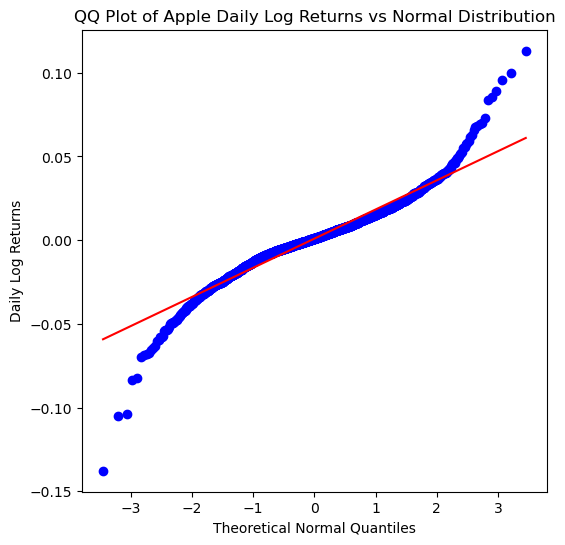

In [3]:
series = log_returns["AAPL"].dropna()

plt.figure(figsize=(6,6))
stats.probplot(series, dist="norm", plot=plt)

plt.title("QQ Plot of Apple Daily Log Returns vs Normal Distribution")
plt.xlabel("Theoretical Normal Quantiles")
plt.ylabel("Daily Log Returns")

plt.show()

Quantile-Return (or QQ) plot reveals deviations from the straight line in extreme quantiles. Both negative and positive extreme returns occur more frequently than predicted by a normal distribution, confiming presence of fat tails in the return distribution.

Kurtosis: 13.273504281576185


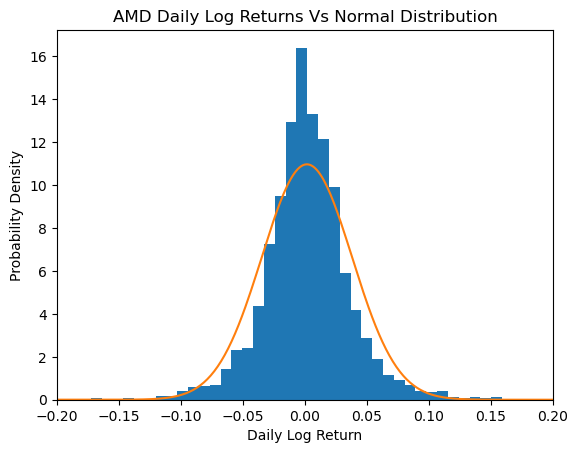

In [6]:
log_returns = np.log(close / close.shift(1))

series_AMD = log_returns["AMD"].dropna()
mu_AMD = series_AMD.mean()
sigma_AMD = series_AMD.std()

x_AMD = np.linspace(series_AMD.min(), series_AMD.max(), 500)
normal_pdf_AMD = norm.pdf(x_AMD, mu_AMD, sigma_AMD)

plt.figure()
plt.hist(series_AMD, bins=80, density=True)
plt.plot(x, normal_pdf_AMD)

plt.title("AMD Daily Log Returns Vs Normal Distribution")
plt.xlabel("Daily Log Return")
plt.ylabel("Probability Density")
plt.xlim(-0.2,0.2)
k = kurtosis(series, fisher=False)
print("Kurtosis:", k)

AMD Case study:  
> Much higher kurtosis 13.27  
> 